# Loan data pipeline

`CustomTransformer` encapsulates the cleaning and feature engineering from `data_learning.ipynb` for use in a scikit-learn `Pipeline`.

In [19]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin


NONE_LABEL = "None"
EPOCH = pd.Timestamp("1970-01-01")

DROP_STATUSES = [
    "Current",
    "In Grace Period",
    "Late (16-30 days)",
]

GOOD_STATUSES = [
    "Fully Paid",
    "Does not meet the credit policy. Status:Fully Paid",
]

BAD_STATUSES = [
    "Charged Off",
    "Default",
    "Does not meet the credit policy. Status:Charged Off",
    "Late (31-120 days)",
]

HIGH_PAY_KEYWORDS = [
    "doctor", "physician", "surgeon", "dentist", "lawyer", "attorney",
    "engineer", "software", "developer", "architect", "consultant",
    "director", "executive", "ceo", "cfo", "vice president", " vp",
    "manager", "professor", "pharmacist", "analyst", "pilot",
    "nurse practitioner", "financial adviser", "investment",
]

LOW_PAY_KEYWORDS = [
    "cashier", "clerk", "server", "waiter", "waitress", "barista",
    "janitor", "cleaner", "housekeep", "dishwash", "crew member",
    "retail", "sales associate", "stock clerk", "security guard",
    "landscap", "laborer", "warehouse", "picker", "packer",
    "helper", "intern", "student", "delivery driver", "fast food",
    "mcdonald", "burger king", "pizza hut", "subway", "starbucks",
]

MTHS_EVENT_COLS = [
    "mths_since_last_delinq",
    "mths_since_last_record",
    "mths_since_last_major_derog",
]

LEAKAGE_OR_UNNECESSARY = [
    "id",
    "member_id",
    "url",
    "title",
    "loan_status",
    "funded_amnt",
    "funded_amnt_inv",
    "out_prncp",
    "out_prncp_inv",
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    "recoveries",
    "collection_recovery_fee",
    "last_pymnt_d",
    "last_pymnt_amnt",
    "last_credit_pull_d",
]

SPARSE_OR_LOW_VALUE = [
    "tot_coll_amt",
    "total_rev_hi_lim",
    "tot_cur_bal",
]

DATE_COLUMNS = [
    "issue_d",
    "earliest_cr_line",
    "last_pymnt_d",
    "next_pymnt_d",
    "last_credit_pull_d",
]


def parse_emp_length(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    if text == "< 1 year":
        return 0.5
    if "+" in text:
        return float(text.split("+")[0])
    return float(text.split()[0])


def job_pay_tier(title):
    if pd.isna(title):
        return "none"
    text = str(title).lower()
    if any(keyword in text for keyword in HIGH_PAY_KEYWORDS):
        return "high"
    if any(keyword in text for keyword in LOW_PAY_KEYWORDS):
        return "low"
    return "medium"


def format_months_since(value):
    if pd.isna(value):
        return NONE_LABEL
    num = float(value)
    return str(int(num)) if num.is_integer() else str(num)


class CustomTransformer(BaseEstimator, TransformerMixin):
    """Replicates preprocessing in data_learning.ipynb (sections 2–10)."""

    def __init__(self, return_label=False):
        self.return_label = return_label

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = self._preprocess(X)
        if self.return_label:
            return df.drop(columns=["label"]), df["label"]
        return df

    def _preprocess(self, X):
        df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

        df = self._drop_useless_columns(df)
        df = self._standardize_missing_values(df)
        df = self._fix_dtypes(df)
        df = self._filter_and_label(df)
        df = self._engineer_features(df)
        df = self._encode_event_columns(df)
        df = self._drop_leaky_and_sparse(df)
        df = self._pre_model_cleanup(df)
        df = self._fill_emp_length_and_annual_inc(df)
        return df

    @staticmethod
    def _drop_useless_columns(df):
        if "Unnamed: 0" in df.columns:
            df = df.drop(columns=["Unnamed: 0"])
        empty_columns = df.columns[df.isna().all()].tolist()
        return df.drop(columns=empty_columns)

    @staticmethod
    def _standardize_missing_values(df):
        text_columns = df.select_dtypes(include=["object", "string"]).columns
        for col in text_columns:
            df[col] = df[col].replace(r"^\s*$", np.nan, regex=True)
        return df

    @staticmethod
    def _fix_dtypes(df):
        df["term"] = df["term"].astype(str).str.extract(r"(\d+)").astype(float)
        for col in DATE_COLUMNS:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], format="%b-%y", errors="coerce")
        for col in ["id", "member_id"]:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")
        return df

    @staticmethod
    def _filter_and_label(df):
        df = df[~df["loan_status"].isin(DROP_STATUSES)].copy()
        status_to_label = {s: 1 for s in GOOD_STATUSES} | {s: 0 for s in BAD_STATUSES}
        df["label"] = df["loan_status"].map(status_to_label)
        return df

    @staticmethod
    def _engineer_features(df):
        df["has_desc"] = df["desc"].notna().astype(int)
        df = df.drop(columns=["desc"])
        df["emp_length"] = df["emp_length"].map(parse_emp_length)
        df["home_ownership"] = (
            df["home_ownership"].replace({"ANY": "OTHER"}).str.upper()
        )
        df["emp_pay_tier"] = df["emp_title"].apply(job_pay_tier)
        return df.drop(columns=["emp_title"])

    @staticmethod
    def _encode_event_columns(df):
        for col in MTHS_EVENT_COLS:
            df[col] = df[col].apply(format_months_since)
        df["next_pymnt_d"] = df["next_pymnt_d"].apply(
            lambda x: pd.Timestamp(x).strftime("%Y-%m-%d") if pd.notna(x) else NONE_LABEL
        )
        return df

    @staticmethod
    def _drop_leaky_and_sparse(df):
        drop_columns = LEAKAGE_OR_UNNECESSARY + SPARSE_OR_LOW_VALUE
        cols_to_drop = [c for c in drop_columns if c in df.columns]
        return df.drop(columns=cols_to_drop)

    @staticmethod
    def _pre_model_cleanup(df):
        df = df.drop(columns=["pymnt_plan", "application_type"], errors="ignore")
        for col in ["issue_d", "earliest_cr_line"]:
            if col in df.columns:
                df[col] = ((df[col] - EPOCH).dt.days).astype("Int64")
        for col in MTHS_EVENT_COLS:
            df[col] = df[col].apply(
                lambda x: -1 if x == NONE_LABEL else int(float(x))
            ).astype("int64")
        df["initial_list_status"] = (
            df["initial_list_status"].str.lower() == "w"
        ).astype("int64")
        df["next_pymnt_d"] = df["next_pymnt_d"].apply(
            lambda x: -1
            if x == NONE_LABEL
            else int((pd.Timestamp(x) - EPOCH).days)
        ).astype("int64")
        return df.drop(columns=["zip_code"], errors="ignore")

    @staticmethod
    def _fill_emp_length_and_annual_inc(df):
        df["emp_length"] = df["emp_length"].fillna(0)
        df["annual_inc"] = df["annual_inc"].fillna(0)
        return df

In [20]:
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
DATA_PATH = "loan_data_2007_2014.csv"

raw_df = pd.read_csv(DATA_PATH, low_memory=False)

prep = CustomTransformer()
cleaned = prep.fit_transform(raw_df)   # (237695, 33) on the full CSV


In [21]:
cleaned.info()

<class 'pandas.DataFrame'>
Index: 237695 entries, 0 to 466283
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   loan_amnt                    237695 non-null  int64  
 1   term                         237695 non-null  float64
 2   int_rate                     237695 non-null  float64
 3   installment                  237695 non-null  float64
 4   grade                        237695 non-null  str    
 5   sub_grade                    237695 non-null  str    
 6   emp_length                   237695 non-null  float64
 7   home_ownership               237695 non-null  str    
 8   annual_inc                   237695 non-null  float64
 9   verification_status          237695 non-null  str    
 10  issue_d                      237695 non-null  Int64  
 11  purpose                      237695 non-null  str    
 12  addr_state                   237695 non-null  str    
 13  dti            

In [22]:
missing_counts = cleaned.isnull().sum()
print(missing_counts)

loan_amnt                        0
term                             0
int_rate                         0
installment                      0
grade                            0
sub_grade                        0
emp_length                       0
home_ownership                   0
annual_inc                       0
verification_status              0
issue_d                          0
purpose                          0
addr_state                       0
dti                              0
delinq_2yrs                     29
earliest_cr_line                29
inq_last_6mths                  29
mths_since_last_delinq           0
mths_since_last_record           0
open_acc                        29
pub_rec                         29
revol_bal                        0
revol_util                     231
total_acc                       29
initial_list_status              0
next_pymnt_d                     0
collections_12_mths_ex_med     145
mths_since_last_major_derog      0
policy_code         

## Splitting Train and Testing data

In [23]:
from sklearn.model_selection import train_test_split

X = cleaned.drop(columns=['label']) 
y = cleaned['label']                

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20,          
    random_state=42,         
    stratify=y             
)

print("Training class distribution:\n", y_train.value_counts(normalize=True))
print("\nTesting class distribution:\n", y_test.value_counts(normalize=True))

Training class distribution:
 label
1    0.785576
0    0.214424
Name: proportion, dtype: float64

Testing class distribution:
 label
1    0.785566
0    0.214434
Name: proportion, dtype: float64


In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, TargetEncoder

CAT_FEATURES = [
    "grade",
    "sub_grade",
    "home_ownership",
    "verification_status",
    "purpose",
    "addr_state",
    "emp_pay_tier",
]
NUM_FEATURES = [c for c in X_train.columns if c not in CAT_FEATURES]

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", TargetEncoder(target_type="binary")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, NUM_FEATURES),
        ("cat", categorical_pipeline, CAT_FEATURES),
    ]
)

# Fit on train only; pass y so TargetEncoder can learn category means
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Train matrix: {X_train_processed.shape}")
print(f"Test matrix:  {X_test_processed.shape}")

# Full modeling pipeline (add your estimator after preprocess)
model_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        # ("classifier", YourEstimator(...)),
    ]
)

Train matrix: (190156, 32)
Test matrix:  (47539, 32)


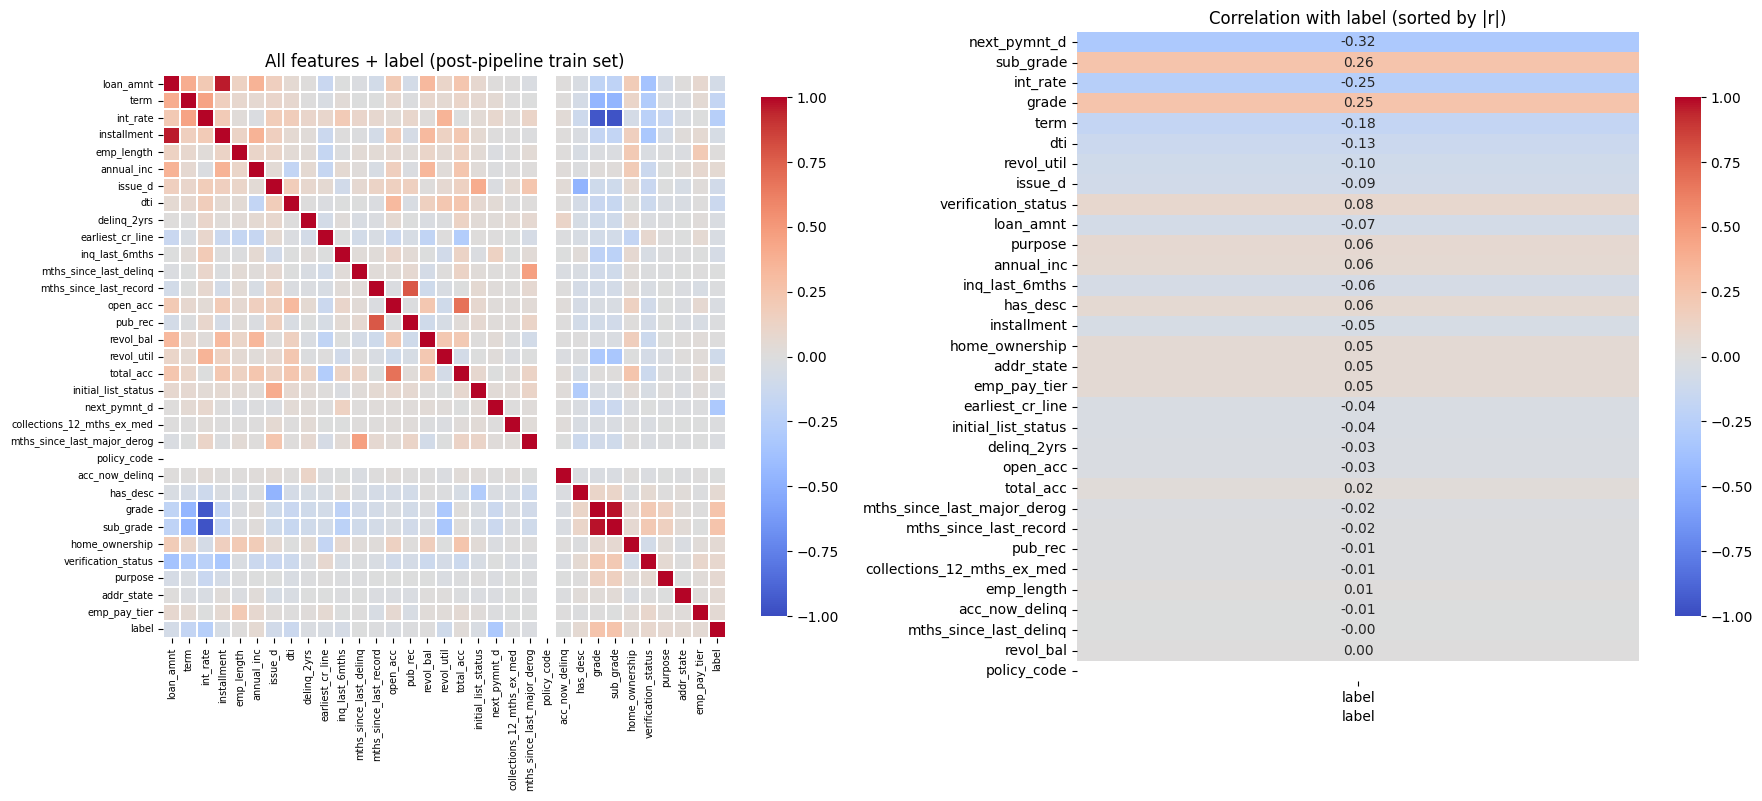

Correlation with label:
 next_pymnt_d                  -0.318901
sub_grade                      0.256355
int_rate                      -0.254426
grade                          0.250317
term                          -0.175858
dti                           -0.126438
revol_util                    -0.096609
issue_d                       -0.091261
verification_status            0.083919
loan_amnt                     -0.072801
purpose                        0.062771
annual_inc                     0.062164
inq_last_6mths                -0.056326
has_desc                       0.056322
installment                   -0.053228
home_ownership                 0.049577
addr_state                     0.049268
emp_pay_tier                   0.048300
earliest_cr_line              -0.036651
initial_list_status           -0.035216
delinq_2yrs                   -0.028033
open_acc                      -0.025621
total_acc                      0.023664
mths_since_last_major_derog   -0.023147
mths_since_last

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# After preprocess pipeline: impute → target-encode (cats) → scale (nums)
PROCESSED_FEATURE_NAMES = NUM_FEATURES + CAT_FEATURES

processed_df = pd.DataFrame(
    X_train_processed,
    columns=PROCESSED_FEATURE_NAMES,
    index=y_train.index,
)
processed_df["label"] = y_train.values

corr = processed_df.corr()
label_corr = corr["label"].drop("label").sort_values(key=lambda s: s.abs(), ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.2,
    cbar_kws={"shrink": 0.8},
    ax=axes[0],
)
axes[0].set_title("All features + label (post-pipeline train set)")
axes[0].tick_params(axis="x", rotation=90, labelsize=7)
axes[0].tick_params(axis="y", labelsize=7)

sns.heatmap(
    label_corr.to_frame(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={"shrink": 0.8},
    ax=axes[1],
)
axes[1].set_title("Correlation with label (sorted by |r|)")
axes[1].set_xlabel("label")

plt.tight_layout()
plt.show()

print("Correlation with label:\n", label_corr)

## Grid search

Tune models with `GridSearchCV` (3-fold stratified CV, scoring = F1 for class 0). Progress is printed per model and per sklearn fit (`verbose=2`).

Best estimators and the fitted preprocessor are saved under `saved_models/` with joblib.

In [ ]:
import time
from pathlib import Path

import joblib
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, ParameterGrid, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

try:
    from xgboost import XGBClassifier

    HAS_XGB = True
except ImportError:
    HAS_XGB = False

BAD_CLASS = 0  # bad / default
XGB_SCALE_POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()
SCORING = make_scorer(f1_score, pos_label=BAD_CLASS)
CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

GRID_SEARCH_CONFIGS = {
    "LogisticRegression": {
        "estimator": LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42,
        ),
        "param_grid": {
            "C": [0.01, 0.1, 1.0, 10.0],
            "solver": ["lbfgs", "saga"],
        },
    },
    "SVM_linear": {
        "estimator": LinearSVC(
            class_weight="balanced",
            random_state=42,
            max_iter=5000,
        ),
        "param_grid": {
            "C": [0.01, 0.1, 1.0, 10.0],
        },
    },
    "RandomForest": {
        "estimator": RandomForestClassifier(
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ),
        "param_grid": {
            "n_estimators": [100, 200],
            "max_depth": [10, 20, None],
            "min_samples_leaf": [1, 5],
        },
    },
    "HistGradientBoosting": {
        "estimator": HistGradientBoostingClassifier(
            class_weight="balanced",
            random_state=42,
        ),
        "param_grid": {
            "max_depth": [5, 10],
            "learning_rate": [0.05, 0.1],
            "max_iter": [100, 200],
        },
    },
}

if HAS_XGB:
    GRID_SEARCH_CONFIGS["XGBoost"] = {
        "estimator": XGBClassifier(
            scale_pos_weight=XGB_SCALE_POS_WEIGHT,
            random_state=42,
            n_jobs=-1,
            eval_metric="logloss",
        ),
        "param_grid": {
            "n_estimators": [100, 200],
            "max_depth": [4, 6, 8],
            "learning_rate": [0.05, 0.1],
            "subsample": [0.8, 1.0],
        },
    }
else:
    print("XGBoost not installed — skip with: pip install xgboost")


def _positive_class_scores(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X)
    return estimator.predict(X)


def grid_search_with_progress(
    model_name,
    estimator,
    param_grid,
    X,
    y,
    *,
    cv=CV,
    scoring=SCORING,
    n_jobs=-1,
    refit=True,
    verbose=2,
    model_index=None,
    model_total=None,
):
    """Run GridSearchCV and print which model / how many fits are scheduled."""
    n_combos = len(list(ParameterGrid(param_grid)))
    n_fits = n_combos * cv.get_n_splits(X, y)

    header = (
        f"Model {model_index}/{model_total}: {model_name}"
        if model_index
        else f"Model: {model_name}"
    )
    print("" + "=" * 60)
    print(header)
    print("=" * 60)
    print(f"  Parameter combinations: {n_combos}")
    print(f"  CV folds: {cv.get_n_splits(X, y)}  ->  total fits: {n_fits}")
    print("  Training now...")

    search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        refit=refit,
        verbose=verbose,
        return_train_score=False,
    )
    t0 = time.perf_counter()
    search.fit(X, y)
    elapsed = time.perf_counter() - t0

    print(f"Finished {model_name} in {elapsed:.1f}s")
    print(f"  Best CV F1 (bad class): {search.best_score_:.4f}")
    print(f"  Best params: {search.best_params_}")
    return search


def run_all_grid_searches(configs, X, y, **grid_kwargs):
    """Grid-search every model in `configs`; returns dict of GridSearchCV results."""
    results = {}
    names = list(configs.keys())
    total = len(names)

    for i, name in enumerate(names, start=1):
        cfg = configs[name]
        results[name] = grid_search_with_progress(
            name,
            cfg["estimator"],
            cfg["param_grid"],
            X,
            y,
            model_index=i,
            model_total=total,
            **grid_kwargs,
        )

    print("" + "=" * 60)
    print("All grid searches complete.")
    print("=" * 60)
    return results


grid_searches = run_all_grid_searches(
    GRID_SEARCH_CONFIGS,
    X_train_processed,
    y_train,
)

grid_summary_rows = []
for name, gs in grid_searches.items():
    best = gs.best_estimator_
    y_pred = best.predict(X_test_processed)
    y_score = _positive_class_scores(best, X_test_processed)
    grid_summary_rows.append(
        {
            "model": name,
            "best_cv_f1_bad": gs.best_score_,
            "best_params": gs.best_params_,
            "test_accuracy": accuracy_score(y_test, y_pred),
            "test_precision_bad": precision_score(
                y_test, y_pred, pos_label=BAD_CLASS, zero_division=0
            ),
            "test_recall_bad": recall_score(
                y_test, y_pred, pos_label=BAD_CLASS, zero_division=0
            ),
            "test_f1_bad": f1_score(y_test, y_pred, pos_label=BAD_CLASS, zero_division=0),
            "test_roc_auc": roc_auc_score(y_test, y_score),
        }
    )

grid_summary_df = pd.DataFrame(grid_summary_rows).sort_values(
    "test_f1_bad", ascending=False
).reset_index(drop=True)
grid_summary_df

In [30]:
SAVE_DIR = Path("saved_models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(preprocessor, SAVE_DIR / "preprocessor.joblib")

for name, gs in grid_searches.items():
    safe_name = name.replace(" ", "_")
    joblib.dump(gs.best_estimator_, SAVE_DIR / f"{safe_name}_best_estimator.joblib")
    joblib.dump(gs, SAVE_DIR / f"{safe_name}_gridsearch.joblib")

    inference_pipeline = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("classifier", gs.best_estimator_),
        ]
    )
    joblib.dump(inference_pipeline, SAVE_DIR / f"{safe_name}_pipeline.joblib")

grid_summary_df.to_csv(SAVE_DIR / "grid_search_summary.csv", index=False)
joblib.dump(grid_summary_df, SAVE_DIR / "grid_search_summary.joblib")

print(f"Saved to {SAVE_DIR.resolve()}:")
for path in sorted(SAVE_DIR.iterdir()):
    print(f"  {path.name}")

Saved to D:\Programming\Book\Part 2\internship\saved_models:
  grid_search_summary.csv
  grid_search_summary.joblib
  HistGradientBoosting_best_estimator.joblib
  HistGradientBoosting_gridsearch.joblib
  HistGradientBoosting_pipeline.joblib
  LogisticRegression_best_estimator.joblib
  LogisticRegression_gridsearch.joblib
  LogisticRegression_pipeline.joblib
  preprocessor.joblib
  RandomForest_best_estimator.joblib
  RandomForest_gridsearch.joblib
  RandomForest_pipeline.joblib
  SVM_linear_best_estimator.joblib
  SVM_linear_gridsearch.joblib
  SVM_linear_pipeline.joblib
  XGBoost_best_estimator.joblib
  XGBoost_gridsearch.joblib
  XGBoost_pipeline.joblib


## MLP (feedforward neural network)

Uses the same `X_train_processed` / `X_test_processed` matrices as grid search (32 numeric features after imputation, target encoding, and scaling).

### Architecture and why each part

| Layer | Choice | Why |
|-------|--------|-----|
| **Input** | 32 features | One row per loan; matches the preprocessor output width. |
| **Dense 128 + ReLU** | First hidden | Wide enough to combine many tabular signals (rate, DTI, grade encoding, state, etc.) without the parameter explosion of matching input width to output. ReLU is the standard default for hidden layers. |
| **Dropout 0.3** | After block 1 | Randomly drops activations during training so the net does not rely on a few neurons; helps on ~190k rows with correlated credit features. |
| **Dense 64 + ReLU** | Second hidden | **Funnel**: each step halves width so the network builds hierarchy (many weak signals → fewer combined patterns → decision). Going 128→64→32 is smoother than one jump to 1 output. |
| **Dropout 0.2** | After block 2 | Slightly lower dropout deeper in the net (common pattern): early layer sees raw feature mix; later layers need more stable combinations. |
| **Dense 32 + ReLU** | Third hidden | Bottleneck before the output: forces a compact credit-risk representation before the final yes/no. 32 mirrors input size but is **learned** mixing, not the raw features. |
| **Dense 1 + Sigmoid** | Output | Binary target (good=1, bad=0): one probability in `[0, 1]`. Sigmoid matches `binary_crossentropy`. |

**Training choices:** `binary_crossentropy` for probabilistic labels; **balanced `class_weight`** so minority class 0 (bad loans) matters more; **early stopping** on a validation slice from train (no peeking at `X_test` for stopping).

In [ ]:
import joblib
from pathlib import Path

import numpy as np
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras

BAD_CLASS = 0
RANDOM_SEED = 42
tf.random.set_seed(RANDOM_SEED)

n_features = X_train_processed.shape[1]

X_tr = np.asarray(X_train_processed, dtype=np.float32)
X_te = np.asarray(X_test_processed, dtype=np.float32)
y_tr = np.asarray(y_train, dtype=np.float32)
y_te = np.asarray(y_test, dtype=np.float32)

# Validation slice from train only (for early stopping — not the test set)
rng = np.random.default_rng(RANDOM_SEED)
val_size = int(0.1 * len(X_tr))
val_idx = rng.choice(len(X_tr), size=val_size, replace=False)
train_idx = np.setdiff1d(np.arange(len(X_tr)), val_idx)

X_fit, y_fit = X_tr[train_idx], y_tr[train_idx]
X_val, y_val = X_tr[val_idx], y_tr[val_idx]

classes = np.unique(y_tr)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_tr)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print("class_weight:", class_weight)

mlp = keras.Sequential(
    [
        keras.layers.Input(shape=(n_features,)),
        # Block 1: wide representation of all 32 inputs
        keras.layers.Dense(128, activation="relu", name="hidden_128"),
        keras.layers.Dropout(0.3, name="dropout_0_3"),
        # Block 2: compress interactions
        keras.layers.Dense(64, activation="relu", name="hidden_64"),
        keras.layers.Dropout(0.2, name="dropout_0_2"),
        # Block 3: bottleneck before decision
        keras.layers.Dense(32, activation="relu", name="hidden_32"),
        # Output: P(good loan) = P(label == 1)
        keras.layers.Dense(1, activation="sigmoid", name="output_prob"),
    ],
    name="loan_default_mlp",
)

mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)

mlp.summary()

history = mlp.fit(
    X_fit,
    y_fit,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=512,
    class_weight=class_weight,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        )
    ],
    verbose=1,
)

# Test metrics (same focus as grid search: class 0 = bad)
y_proba = mlp.predict(X_te, verbose=0).ravel()
y_pred = (y_proba >= 0.5).astype(int)

mlp_metrics = {
    "accuracy": accuracy_score(y_te, y_pred),
    "precision_bad": precision_score(y_te, y_pred, pos_label=BAD_CLASS, zero_division=0),
    "recall_bad": recall_score(y_te, y_pred, pos_label=BAD_CLASS, zero_division=0),
    "f1_bad": f1_score(y_te, y_pred, pos_label=BAD_CLASS, zero_division=0),
    "roc_auc": roc_auc_score(y_te, y_proba),
}
print("\nMLP test metrics:")
for k, v in mlp_metrics.items():
    print(f"  {k}: {v:.4f}")

print("\nClassification report:")
print(classification_report(y_te, y_pred, digits=3))

class_weight: {0: 2.3318291067837347, 1: 0.6364756128583096}


Model: "loan_default_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_128 (Dense)              │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_0_3 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_64 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_0_2 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_32 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_prob (Dense)             │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,593 (57.00 KB)

 Trainable params: 14,593 (57.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - auc: 0.7171 - loss: 0.6072 - precision: 0.8713 - recall: 0.6758 - val_auc: 0.7529 - val_loss: 0.5648 - val_precision: 0.8817 - val_recall: 0.7275
Epoch 2/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7427 - loss: 0.5831 - precision: 0.8792 - recall: 0.7023 - val_auc: 0.7548 - val_loss: 0.5593 - val_precision: 0.8825 - val_recall: 0.7292
Epoch 3/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7469 - loss: 0.5795 - precision: 0.8809 - recall: 0.7030 - val_auc: 0.7551 - val_loss: 0.5575 - val_precision: 0.8833 - val_recall: 0.7166
Epoch 4/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7488 - loss: 0.5776 - precision: 0.8809 - recall: 0.7048 - val_auc: 0.7555 - val_loss: 0.5576 - val_precision: 0.8822 - val_recall: 0.7293
Epoch 5/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7506 - loss: 0.5762 - precision: 0.8819 - recall: 0.7056 - val_auc: 0.7561 - val_loss: 0.5574 - val_precision: 0.8829 - val_recall: 0.7234


In [ ]:
SAVE_DIR = Path("saved_models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(mlp, SAVE_DIR / "loan_default_mlp.joblib")
joblib.dump(mlp_metrics, SAVE_DIR / "mlp_test_metrics.joblib")
print(f"\nSaved: {SAVE_DIR / 'loan_default_mlp.joblib'}")
print(f"Saved: {SAVE_DIR / 'mlp_test_metrics.joblib'}")